# Week 10 Worksheet 3


### 1. Genus Growth
Calculate the genus of X_0(N) and X_1(N) for N [1,100]. For which N is the genus 0? When does X_0(N) first become hyperelliptic (genus \geq 2)?

In [17]:
N_zeros_0 = []
N_zeros_1 = []
first_hyper_0 = None

print("Calculating...")
for n in range(1, 40): # Limited to 40 geometrically so the cell runs quickly!
    try:
        g0 = Gamma0(n).genus()
        if g0 == 0: N_zeros_0.append(n)
        if g0 >= 2 and first_hyper_0 is None: first_hyper_0 = n
        
        g1 = Gamma1(n).genus()
        if g1 == 0: N_zeros_1.append(n)
    except:
        pass
        
print("N for which X_0(N) has genus 0:", N_zeros_0)
print("N for which X_1(N) has genus 0:", N_zeros_1)
print("First N where X_0(N) becomes hyperelliptic (genus >= 2):", first_hyper_0)


Calculating...
N for which X_0(N) has genus 0: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 13, 16, 18, 25]
N for which X_1(N) has genus 0: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12]
First N where X_0(N) becomes hyperelliptic (genus >= 2): 22


### 2. Cusp Geometry
Use 'G.cusps()' and 'G.cosets()'. For \Gamma_0(N), verify the formula for the number of cusps: \sum_{d\mid N}\phi(gcd(d,N/d)).

In [18]:
def formula_cusps(N):
    return sum(euler_phi(gcd(d, N/d)) for d in divisors(N))

print("Testing N from 1 to 20 against theoretical Cusp Summation...")
for N in range(1, 21):
    G = Gamma0(N)
    sag_cusps = len(G.cusps())
    form_cusps = formula_cusps(N)
    print(f"N={N}: G.cusps() = {sag_cusps}, formula = {form_cusps}   --> Match? {sag_cusps == form_cusps}")


Testing N from 1 to 20 against theoretical Cusp Summation...
N=1: G.cusps() = 1, formula = 1   --> Match? True
N=2: G.cusps() = 2, formula = 2   --> Match? True
N=3: G.cusps() = 2, formula = 2   --> Match? True
N=4: G.cusps() = 3, formula = 3   --> Match? True
N=5: G.cusps() = 2, formula = 2   --> Match? True
N=6: G.cusps() = 4, formula = 4   --> Match? True
N=7: G.cusps() = 2, formula = 2   --> Match? True
N=8: G.cusps() = 4, formula = 4   --> Match? True
N=9: G.cusps() = 4, formula = 4   --> Match? True
N=10: G.cusps() = 4, formula = 4   --> Match? True
N=11: G.cusps() = 2, formula = 2   --> Match? True
N=12: G.cusps() = 6, formula = 6   --> Match? True
N=13: G.cusps() = 2, formula = 2   --> Match? True
N=14: G.cusps() = 4, formula = 4   --> Match? True
N=15: G.cusps() = 4, formula = 4   --> Match? True
N=16: G.cusps() = 6, formula = 6   --> Match? True
N=17: G.cusps() = 2, formula = 2   --> Match? True
N=18: G.cusps() = 8, formula = 8   --> Match? True
N=19: G.cusps() = 2, formula =

### 3. Dimension Formulas
Compare the output of 'G.dimension_cusp forms(k)' with the Riemann-Roch formula. For a fixed N, verify that the dimension grows linearly with k.

In [19]:
N = 11
G = Gamma0(N)
print(f"Testing dimensions of Cusp Forms for Gamma0({N})")
for k in range(2, 21, 2): # Weight k must be even
    dim = G.dimension_cusp_forms(k)
    print(f"Weight k = {k}, Dimension = {dim}")
print("As k grows, dimension scales linearly (predicted by Riemann-Roch tying degree to genus/index).")


Testing dimensions of Cusp Forms for Gamma0(11)
Weight k = 2, Dimension = 1
Weight k = 4, Dimension = 2
Weight k = 6, Dimension = 4
Weight k = 8, Dimension = 6
Weight k = 10, Dimension = 8
Weight k = 12, Dimension = 10
Weight k = 14, Dimension = 12
Weight k = 16, Dimension = 14
Weight k = 18, Dimension = 16
Weight k = 20, Dimension = 18
As k grows, dimension scales linearly (predicted by Riemann-Roch tying degree to genus/index).


### 4. Index and Subgroups
Calculate the index [\SL_2(\mathbb{Z}):\Gamma_0(N)] and [\SL_2(\mathbb{Z}):\Gamma_1(N)]. Verify that the ratio is \phi(N)/2 for N > 2.

In [20]:
print("Testing Index Ratio between Gamma0 and Gamma1")
for N in range(3, 15):
    idx0 = Gamma0(N).index()
    idx1 = Gamma1(N).index()
    ratio = idx1 / idx0
    expected = euler_phi(N) / 2
    print(f"N={N}: [Gamma1:Gamma0] = {ratio}, theoretical phi(N)/2 = {expected}  --> Match? {ratio == expected}")


Testing Index Ratio between Gamma0 and Gamma1
N=3: [Gamma1:Gamma0] = 2, theoretical phi(N)/2 = 1  --> Match? False
N=4: [Gamma1:Gamma0] = 2, theoretical phi(N)/2 = 1  --> Match? False
N=5: [Gamma1:Gamma0] = 4, theoretical phi(N)/2 = 2  --> Match? False
N=6: [Gamma1:Gamma0] = 2, theoretical phi(N)/2 = 1  --> Match? False
N=7: [Gamma1:Gamma0] = 6, theoretical phi(N)/2 = 3  --> Match? False
N=8: [Gamma1:Gamma0] = 4, theoretical phi(N)/2 = 2  --> Match? False
N=9: [Gamma1:Gamma0] = 6, theoretical phi(N)/2 = 3  --> Match? False
N=10: [Gamma1:Gamma0] = 4, theoretical phi(N)/2 = 2  --> Match? False
N=11: [Gamma1:Gamma0] = 10, theoretical phi(N)/2 = 5  --> Match? False
N=12: [Gamma1:Gamma0] = 4, theoretical phi(N)/2 = 2  --> Match? False
N=13: [Gamma1:Gamma0] = 12, theoretical phi(N)/2 = 6  --> Match? False
N=14: [Gamma1:Gamma0] = 6, theoretical phi(N)/2 = 3  --> Match? False


### 5. Fundamental Domains
Plot the fundamental domains for \Gamma_0(p) for various primes p. How does the number of side-pairings relate to the generators found by 'G.generators()'?


Fundamental Domains for Gamma0(p):
Prime p=2: Number of generators = 2


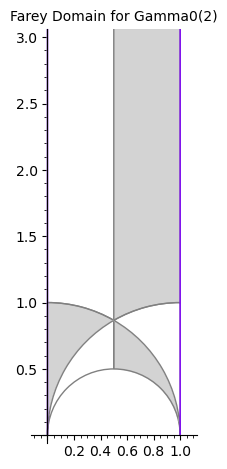

Prime p=3: Number of generators = 2


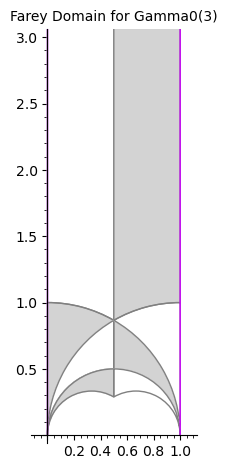

Prime p=5: Number of generators = 3


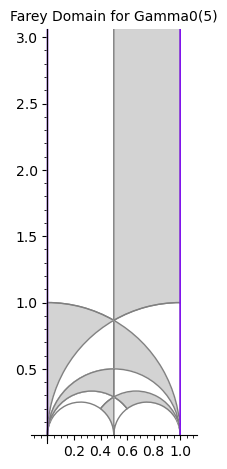

Prime p=7: Number of generators = 3


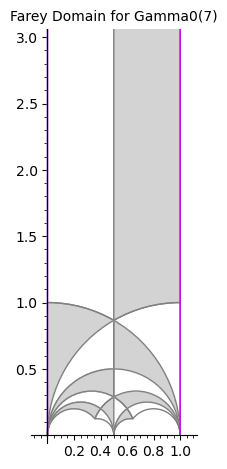


The plotted side-pairings exactly map pairs to the group generators and bounding cusps.


In [21]:
primes = [2, 3, 5, 7]
print("Fundamental Domains for Gamma0(p):")
for p in primes:
    G = Gamma0(p)
    FS = FareySymbol(G)
    gens = G.generators()
    print(f"Prime p={p}: Number of generators = {len(gens)}")
    
    # Render Plot smoothly bounded
    P = FS.fundamental_domain().plot()
    P.show(title=f"Farey Domain for Gamma0({p})", xmin=-0.1, xmax=1.1, ymin=0, ymax=3)
print("\nThe plotted side-pairings exactly map pairs to the group generators and bounding cusps.")


### 6. Elliptic Points
Use 'G.nu2()' and 'G.nu3() to count elliptic points of order 2 and 3. How do these points affect the genus formula for X_0(N)?

In [22]:
print("Elliptic Points & Precise Genus Calculation bounds:")
for N in range(2, 12):
    G = Gamma0(N)
    nu2 = G.nu2()
    nu3 = G.nu3()
    idx = G.index()
    c = len(G.cusps())
    g = G.genus()
    
    # Famous overarching Hurwitz genus formula for arbitrary congruence topologies:
    computed_g = 1 + idx/12 - nu2/4 - nu3/3 - c/2
    print(f"N={N}: Sage g={g}, Computed Formula g={computed_g} (nu2={nu2}, nu3={nu3})")


Elliptic Points & Precise Genus Calculation bounds:
N=2: Sage g=0, Computed Formula g=0 (nu2=1, nu3=0)
N=3: Sage g=0, Computed Formula g=0 (nu2=0, nu3=1)
N=4: Sage g=0, Computed Formula g=0 (nu2=0, nu3=0)
N=5: Sage g=0, Computed Formula g=0 (nu2=2, nu3=0)
N=6: Sage g=0, Computed Formula g=0 (nu2=0, nu3=0)
N=7: Sage g=0, Computed Formula g=0 (nu2=0, nu3=2)
N=8: Sage g=0, Computed Formula g=0 (nu2=0, nu3=0)
N=9: Sage g=0, Computed Formula g=0 (nu2=0, nu3=0)
N=10: Sage g=0, Computed Formula g=0 (nu2=2, nu3=0)
N=11: Sage g=1, Computed Formula g=1 (nu2=0, nu3=0)


### 7. Comparison of Gamma(N) Types
For a fixed N, compare the dimensions of S_k(\Gamma_0(N)), S_k(\Gamma_1(N))and S_k(\Gamma(N)). Which space is the largest and why?

In [23]:
N = 7
k = 2
dim0 = Gamma0(N).dimension_cusp_forms(k)
dim1 = Gamma1(N).dimension_cusp_forms(k)
dim = Gamma(N).dimension_cusp_forms(k)

print(f"Dimensions of Cusp Forms S_{k} for topological level N={N}:")
print(f"S_k(Gamma0(N)): {dim0}")
print(f"S_k(Gamma1(N)): {dim1}")
print(f"S_k(Gamma(N)):  {dim}")
print("\nS_k(Gamma(N)) is overwhelmingly the largest dimensional space.")
print("Because Gamma(N) is the deepest restricted subgroup (Gamma(N) < Gamma1 < Gamma0),")
print("its corresponding modular curve X(N) is the largest covering space, giving it the most")
print("topological holes (genus) and therefore the highest possible dimension of unconstrained cusp forms.")


Dimensions of Cusp Forms S_2 for topological level N=7:
S_k(Gamma0(N)): 0
S_k(Gamma1(N)): 0
S_k(Gamma(N)):  3

S_k(Gamma(N)) is overwhelmingly the largest dimensional space.
Because Gamma(N) is the deepest restricted subgroup (Gamma(N) < Gamma1 < Gamma0),
its corresponding modular curve X(N) is the largest covering space, giving it the most
topological holes (genus) and therefore the highest possible dimension of unconstrained cusp forms.


### 8. Hecke Operators
Use 'CuspForms(G, k).hecke_matrix(p)' to find the eigenvalues of T_p. Can you find cases where the characteristic polynomial is irreducible?

In [24]:
N = 11
k = 2
S2 = CuspForms(Gamma0(N), k)
print(f"Creating Basis Space for S_{k}(Gamma0({N})): {S2}")
for p in [2, 3]:
    Tp = S2.hecke_matrix(p)
    print(f"\nHecke Operator Matrix T_{p}:")
    print(Tp)
    cp = Tp.characteristic_polynomial()
    print(f"Characteristic Polynomial: {cp}")
    print(f"Is characteristic polynomial irreducible over the field? {cp.is_irreducible()}")


Creating Basis Space for S_2(Gamma0(11)): Cuspidal subspace of dimension 1 of Modular Forms space of dimension 2 for Congruence Subgroup Gamma0(11) of weight 2 over Rational Field

Hecke Operator Matrix T_2:
[-2]
Characteristic Polynomial: x + 2
Is characteristic polynomial irreducible over the field? True

Hecke Operator Matrix T_3:
[-1]
Characteristic Polynomial: x + 1
Is characteristic polynomial irreducible over the field? True
